# 📊 Exploratory Data Analysis (EDA) on Retail Sales Data

### Submitted By:
**Rahul Gaonkar**

---

## Objective

The objective of this project is to perform a comprehensive Exploratory Data Analysis (EDA) on a retail sales dataset to uncover sales patterns, customer behavior, product performance, and key business insights. The analysis is performed using Python, Pandas, Matplotlib, and Seaborn in Jupyter Notebook.

## Tools & Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset Description

The dataset contains retail sales transaction records, including customer demographics, product details, order quantity, revenue, cost, profit, and transaction dates. The analysis focuses on identifying sales trends, customer purchasing behavior, product performance, and relationships between numerical variables to support data-driven business decisions.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
%matplotlib inline

In [2]:
import pandas as pd

df = pd.read_csv("Customer_Segmentation_py.csv")

df.head()

,Date,Day,Month,Year,Customer_Age,Age_Group,Customer_Gender,Country,State,Product_Category,Sub_Category,Product,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
0,26/11/2013,26,November,2013,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
1,26/11/2015,26,November,2015,19,Youth (<25),M,Canada,British Columbia,Accessories,Bike Racks,Hitch Rack - 4-Bike,8,45,120,590,360,950
2,23/03/2014,23,March,2014,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,23,45,120,1366,1035,2401
3,23/03/2016,23,March,2016,49,Adults (35-64),M,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,20,45,120,1188,900,2088
4,15/05/2014,15,May,2014,47,Adults (35-64),F,Australia,New South Wales,Accessories,Bike Racks,Hitch Rack - 4-Bike,4,45,120,238,180,418


In [3]:
print("Shape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nMissing Values")
print(df.isnull().sum())

Shape of Dataset
(113036, 18)

Column Names
Index(['Date', 'Day', 'Month', 'Year', 'Customer_Age', 'Age_Group',
       'Customer_Gender', 'Country', 'State', 'Product_Category',
       'Sub_Category', 'Product', 'Order_Quantity', 'Unit_Cost', 'Unit_Price',
       'Profit', 'Cost', 'Revenue'],
      dtype='object')

Data Types
Date                object
Day                  int64
Month               object
Year                 int64
Customer_Age         int64
Age_Group           object
Customer_Gender     object
Country             object
State               object
Product_Category    object
Sub_Category        object
Product             object
Order_Quantity       int64
Unit_Cost            int64
Unit_Price           int64
Profit               int64
Cost                 int64
Revenue              int64
dtype: object

Missing Values
Date                0
Day                 0
Month               0
Year                0
Customer_Age        0
Age_Group           0
Customer_Gender     0
Co

In [4]:
numerical = df.select_dtypes(include=np.number)

numerical.describe()

,Day,Year,Customer_Age,Order_Quantity,Unit_Cost,Unit_Price,Profit,Cost,Revenue
count,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000,113036.000000
mean,15.665753,2014.401739,35.919212,11.901660,267.296366,452.938427,285.051665,469.318695,754.370360
std,8.781567,1.272510,11.021936,9.561857,549.835483,922.071219,453.887443,884.866118,1309.094674
min,1.000000,2011.000000,17.000000,1.000000,1.000000,2.000000,-30.000000,1.000000,2.000000
25%,8.000000,2013.000000,28.000000,2.000000,2.000000,5.000000,29.000000,28.000000,63.000000
50%,16.000000,2014.000000,35.000000,10.000000,9.000000,24.000000,101.000000,108.000000,223.000000
75%,23.000000,2016.000000,43.000000,20.000000,42.000000,70.000000,358.000000,432.000000,800.000000
max,31.000000,2016.000000,87.000000,32.000000,2171.000000,3578.000000,15096.000000,42978.000000,58074.000000


In [5]:
numerical.mean()

Day                 15.665753
Year              2014.401739
Customer_Age        35.919212
Order_Quantity      11.901660
Unit_Cost          267.296366
Unit_Price         452.938427
Profit             285.051665
Cost               469.318695
Revenue            754.370360
dtype: float64

In [8]:
numerical.median()

Day                 16.0
Year              2014.0
Customer_Age        35.0
Order_Quantity      10.0
Unit_Cost            9.0
Unit_Price          24.0
Profit             101.0
Cost               108.0
Revenue            223.0
dtype: float64

In [9]:
numerical.mode().iloc[0]

Day                 24.0
Year              2014.0
Customer_Age        31.0
Order_Quantity       1.0
Unit_Cost            2.0
Unit_Price           5.0
Profit               3.0
Cost              1252.0
Revenue             35.0
Name: 0, dtype: float64

In [10]:
numerical.std()

Day                  8.781567
Year                 1.272510
Customer_Age        11.021936
Order_Quantity       9.561857
Unit_Cost          549.835483
Unit_Price         922.071219
Profit             453.887443
Cost               884.866118
Revenue           1309.094674
dtype: float64

Observation
Revenue has high variation indicating different order sizes.
Customer age is centered around adults.
Profit also varies significantly.

In [11]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

df["Month_Year"] = df["Date"].dt.to_period("M")

df["Quarter"] = df["Date"].dt.to_period("Q")

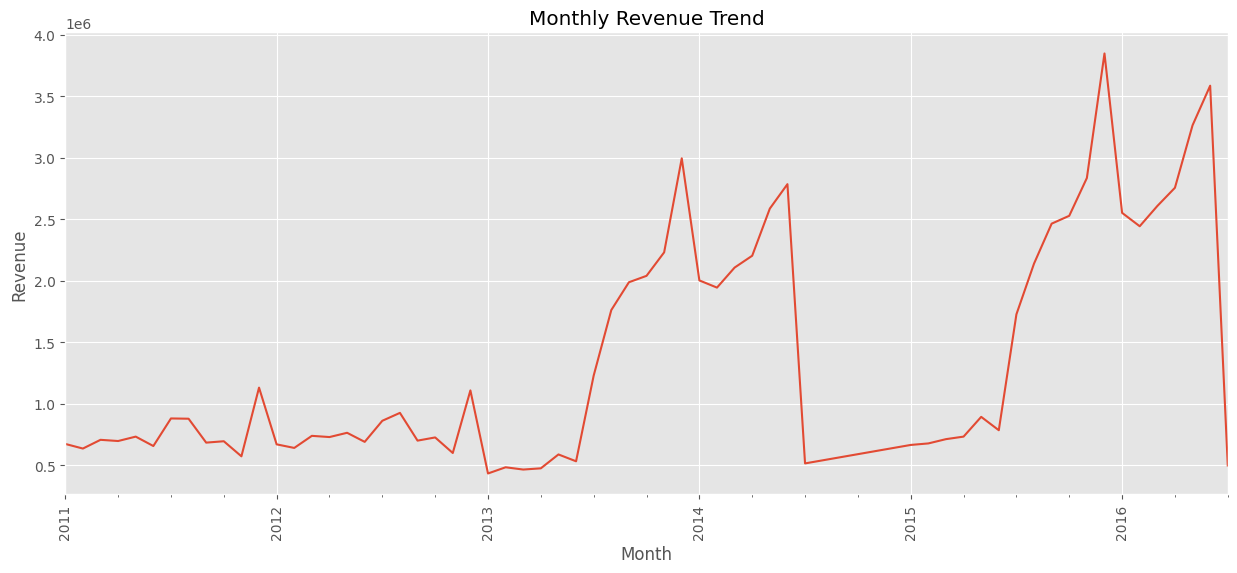

In [12]:
monthly_sales = df.groupby("Month_Year")["Revenue"].sum()

plt.figure(figsize=(15,6))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=90)

plt.show()

### Observation

- Monthly revenue varies throughout the year, indicating seasonal purchasing patterns.
- Certain months show higher sales, likely due to promotions or increased customer demand.
- Overall, sales remain relatively consistent without any prolonged decline.

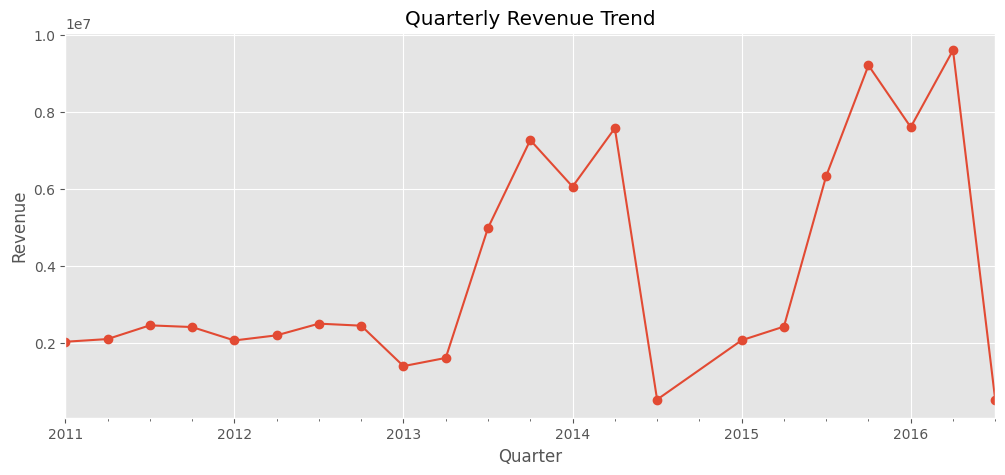

In [13]:
quarter_sales = df.groupby("Quarter")["Revenue"].sum()

plt.figure(figsize=(12,5))

quarter_sales.plot(marker='o')

plt.title("Quarterly Revenue Trend")

plt.xlabel("Quarter")

plt.ylabel("Revenue")

plt.show()

### Observation

- Quarterly sales fluctuate across the year, showing differences in customer demand.
- Some quarters generate higher revenue than others, suggesting seasonal business performance.
- These trends can help the business plan inventory and marketing activities more effectively.

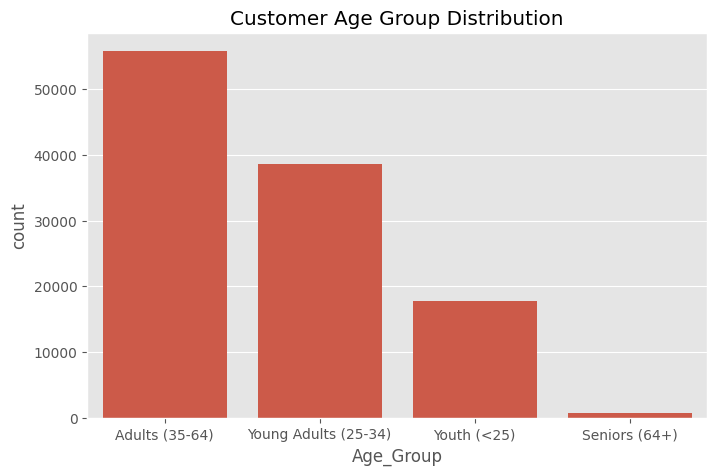

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,
              x="Age_Group",
              order=df["Age_Group"].value_counts().index)

plt.title("Customer Age Group Distribution")

plt.show()

### Observation

- Adults make up the largest portion of the customer base.
- Young Adults are the second-largest customer segment.
- Seniors contribute the smallest share of customers, indicating lower engagement from this age group.

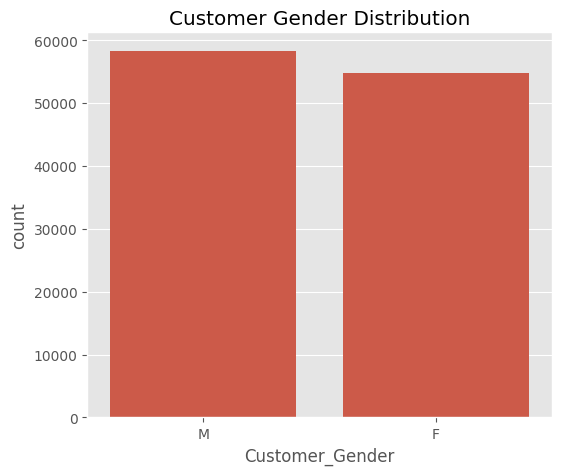

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,
              x="Customer_Gender")

plt.title("Customer Gender Distribution")

plt.show()

### Observation

- The customer base is nearly evenly distributed between male and female customers.
- No significant gender imbalance is observed.
- Marketing campaigns can be designed to target both genders equally.

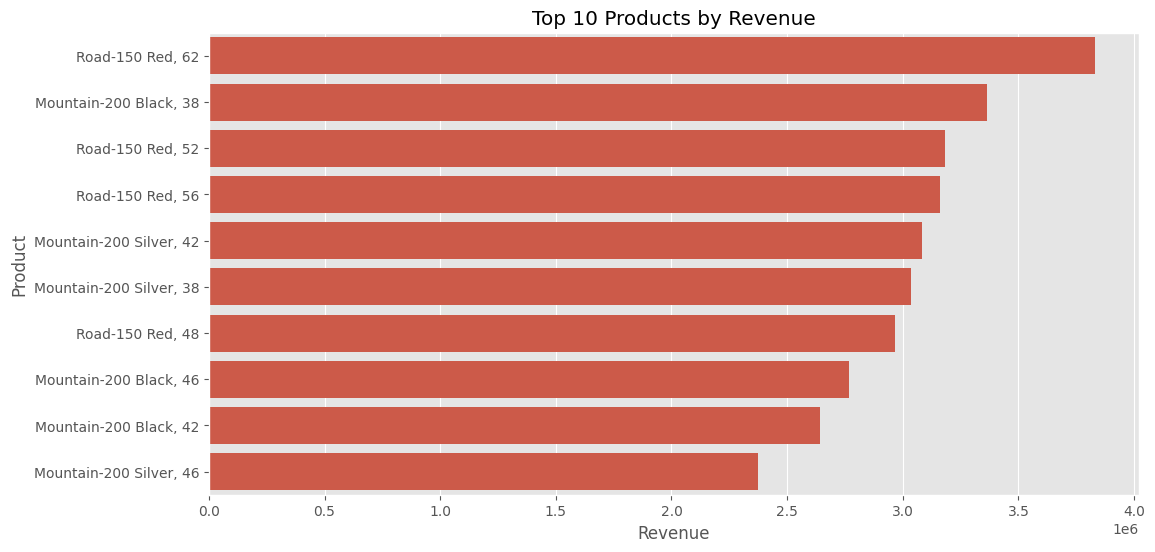

In [16]:
top_products = (df.groupby("Product")["Revenue"]
                  .sum()
                  .sort_values(ascending=False)
                  .head(10))

plt.figure(figsize=(12,6))

sns.barplot(x=top_products.values,
            y=top_products.index)

plt.title("Top 10 Products by Revenue")

plt.xlabel("Revenue")

plt.ylabel("Product")

plt.show()

### Observation

- A small number of products contribute a large percentage of total revenue.
- These products are the key revenue generators for the business.
- Ensuring sufficient stock for these products can improve customer satisfaction and sales.

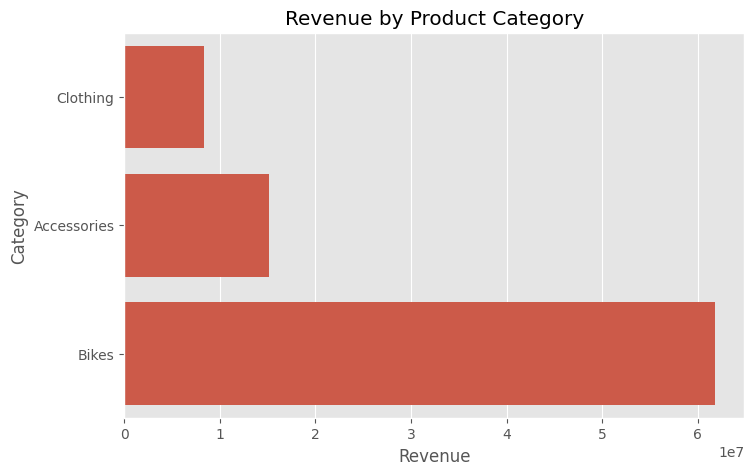

In [17]:
category_sales = df.groupby("Product_Category")["Revenue"].sum().sort_values()

plt.figure(figsize=(8,5))

sns.barplot(x=category_sales.values,
            y=category_sales.index)

plt.title("Revenue by Product Category")

plt.xlabel("Revenue")

plt.ylabel("Category")

plt.show()

### Observation

- Revenue differs across product categories.
- Some categories consistently generate higher sales than others.
- Lower-performing categories may require promotional offers or improved marketing strategies.

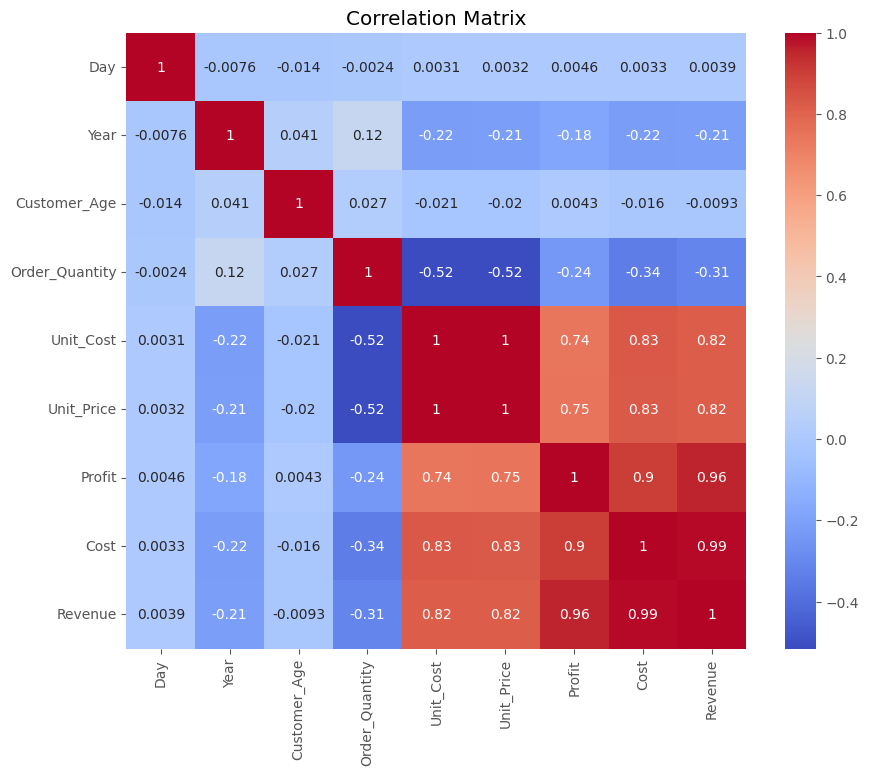

In [18]:
plt.figure(figsize=(10,8))

sns.heatmap(numerical.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

### Observation

- Revenue has a strong positive correlation with Profit and Cost.
- Unit Price and Unit Cost also show a positive relationship.
- Customer Age has little correlation with revenue, indicating that purchasing value is not strongly influenced by age.

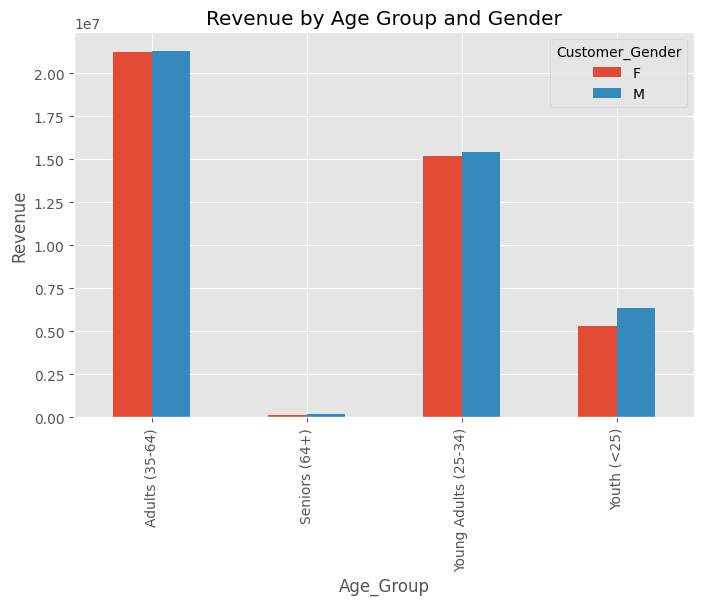

In [19]:
pivot = df.pivot_table(values="Revenue",
                       index="Age_Group",
                       columns="Customer_Gender",
                       aggfunc="sum")

pivot.plot(kind="bar",
           figsize=(8,5))

plt.title("Revenue by Age Group and Gender")

plt.ylabel("Revenue")

plt.show()

### Observation

- Adult customers generate the highest revenue across both genders.
- Revenue contribution is relatively balanced between male and female customers.
- Adults represent the most valuable customer segment for the business.

# Conclusion

### Key Findings

- Adult customers are the largest and most valuable customer segment.
- A small number of products generate a significant share of total revenue.
- Sales show seasonal fluctuations across different months and quarters.
- Revenue is strongly associated with Profit and Cost.
- Customer purchases are fairly balanced across genders.

### Business Recommendations

1. Maintain sufficient inventory for top-selling products to prevent stock shortages.

2. Focus marketing campaigns on adult customers, as they generate the highest revenue.

3. Introduce promotional offers during low-sales periods to reduce seasonal fluctuations.

4. Invest more in high-performing product categories while improving the performance of lower-selling categories.

5. Expand marketing efforts in high-revenue countries to maximize business growth.